<a href="https://colab.research.google.com/github/KrisTinaShch/TM_CNN/blob/Mnist_DataSet/MNIST_Sorting_Letters_By_Index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
torch.manual_seed(25)
np.random.seed(25)

In [25]:
transform = transforms.Compose([
    transforms.ToTensor(), # переводит изображение в тензоры
    transforms.Normalize((0.13,),(0.3,)) # нормализация тензора, настраиваем чтобы распределение было от 0 до 1
])

In [26]:
# Скачиваем MNIST датасеты - сразу разделяем их на тестовые и тренировочные датасеты. Параметры в основном одинаковые
# но в тестовой выборке параметр train должен быть False
train_dataset = datasets.MNIST('./data',train=True,download=True,transform=transform)
test_dataset = datasets.MNIST('./data',train=False,download=True,transform=transform)

In [27]:
# переводим данные в таблицу с учетом разбиением батчами
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(train_dataset,batch_size=64,shuffle=False)

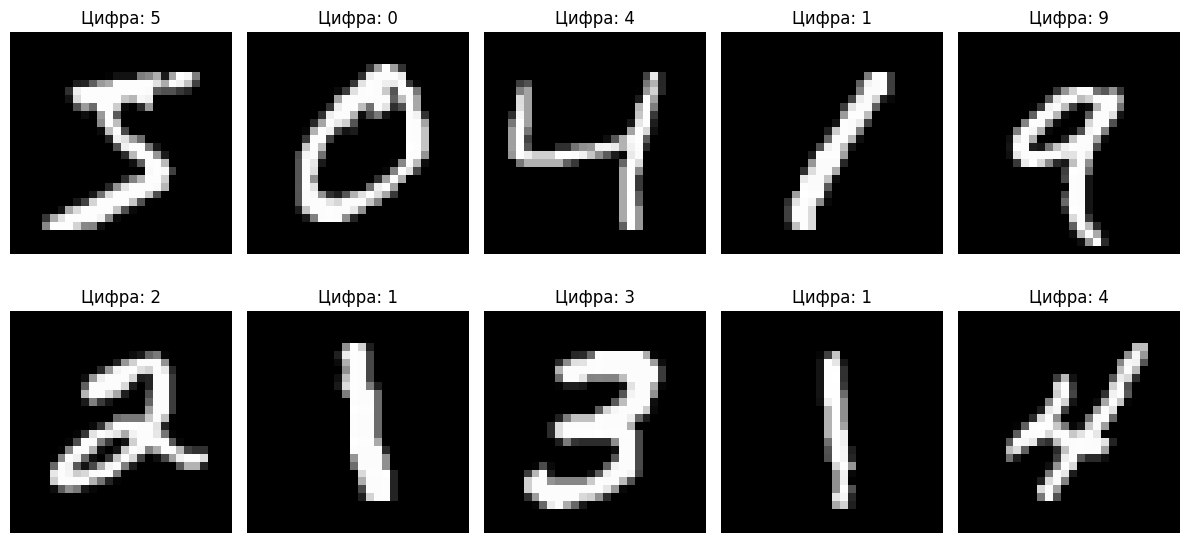

In [28]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Цифра: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [29]:
# Создание обычной многослойной модели
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(784,128)
    self.fc2 = nn.Linear(128,64)
    self.fc3 = nn.Linear(64,10)
    self.relu = nn.ReLU()

  def forward(self,x):
    x = self.flatten(x)
    x = self.relu(self.fc1(x))
    x = self.relu(self.fc2(x))
    x = self.fc3(x)
    return x